In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings(action = "ignore")

In [ ]:
### importing the csv files
store = pd.read_csv("SuperStore_DataSet.csv")

In [3]:
store_copy = store.copy()

In [ ]:
### checking for various columns
store_copy.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [5]:
### Recency, ## Frequency ### Money
store_copy.shape

(51290, 24)

In [6]:
store_copy.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           1
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [7]:
### check the datatype for order date
print(store_copy["Order Date"].dtype)

object


In [8]:
store_copy.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,42433,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,TB-11280,Toby Braunhardt,Consumer,Constantine,Constantine,...,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",408.300,2,0.0,106.140,35.46,Medium
1,22253,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,JH-15985,Joseph Holt,Consumer,Wagga Wagga,New South Wales,...,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",120.366,3,0.1,36.036,9.72,Medium


In [9]:
store_copy.insert(3, "Order_Date", pd.to_datetime(store_copy["Order Date"], format = "%d/%m/%Y", errors = "coerce"))

In [10]:
### We are selecting "Order Date" and "Order_Date"
store_copy[["Order Date", "Order_Date"]]

,Order Date,Order_Date
0,1/1/2011,2011-01-01
1,1/1/2011,2011-01-01
2,1/1/2011,2011-01-01
3,1/1/2011,2011-01-01
4,1/1/2011,2011-01-01
...,...,...
51285,31-12-2014,NaT
51286,31-12-2014,NaT
51287,31-12-2014,NaT
51288,31-12-2014,NaT


In [11]:
#### Show all missing values for "order_date"
store_copy[store_copy["Order_Date"].isna()][["Order Date", "Order_Date"]]

,Order Date,Order_Date
20067,13-01-2011,NaT
20068,13-01-2011,NaT
20069,13-01-2011,NaT
20070,13-01-2011,NaT
20071,13-01-2011,NaT
...,...,...
51285,31-12-2014,NaT
51286,31-12-2014,NaT
51287,31-12-2014,NaT
51288,31-12-2014,NaT


In [12]:
#### Actual conversion of Order Date
store_copy["Order Date"] = pd.to_datetime(store_copy["Order Date"], format = "mixed", dayfirst = True)

In [13]:
print(store_copy["Order Date"].dtype)

datetime64[ns]


In [14]:
store_copy["Order Date"].isnull().sum()

np.int64(0)

In [15]:
### Drop the "Order_Date"
store_copy.drop(columns = "Order_Date", inplace = True)
### Alternative drop method
# store_copy.drop("Order_Date", axis = 1, inplace = True)

In [16]:
store_copy.shape

(51290, 24)

In [17]:
store_copy["Customer ID"].nunique()

1590

### Recency

In [18]:
### Reference date to enable date count
ref_date = store_copy["Order Date"].max() + pd.Timedelta(days = 1)

In [19]:
#### Recent date of customer, ie. last time the customer visited
recent = store_copy.groupby("Customer ID")["Order Date"].max()

In [20]:
### Calculate the number of days from the recent date and reference date
recency = (ref_date - recent).dt.days

### Frequency

In [21]:
### For this dataset, we will use the order id to track customer's engagement 
### with the company. Eventually, we will group by the Customer ID
freq = store_copy.groupby("Customer ID")["Order ID"].nunique()

### Monetary

In [22]:
amount = store_copy.groupby("Customer ID")["Sales"].sum()

### RFM - DataFrame

In [23]:
rfm_frame = pd.DataFrame({"Recency": recency, "Frequency": freq, "Monetary": amount})

In [24]:
rfm_frame.shape

(1590, 3)

### EDA

#### Boxplot

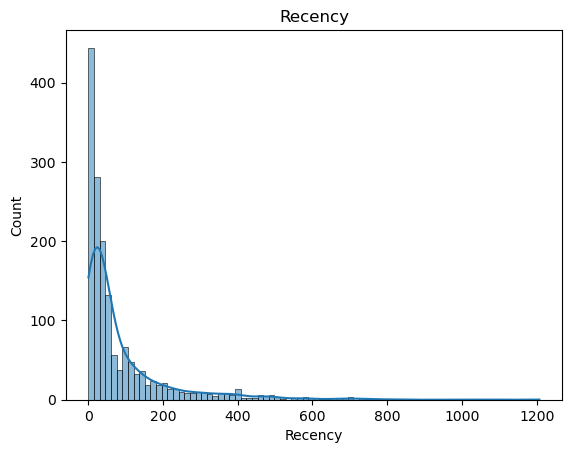

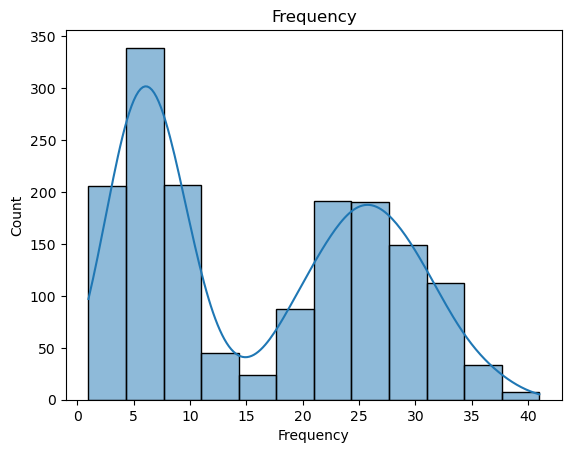

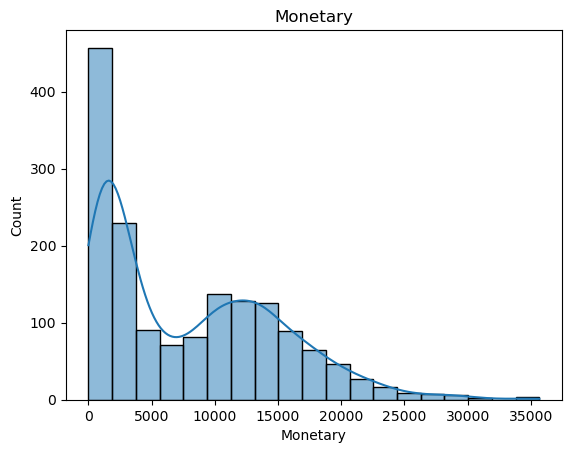

In [25]:
for col in rfm_frame.columns:
    sns.histplot(rfm_frame[col], kde = True)
    plt.title(col)
    plt.show()

#### Box plot

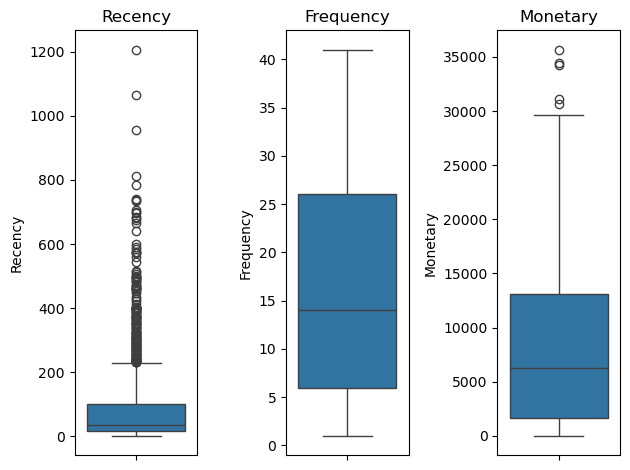

In [26]:
for item, col in enumerate(rfm_frame.columns, 1):
    plt.subplot(1,3, item)
    sns.boxplot(rfm_frame[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Feature Engineering

#### Log Transformation

In [27]:
### Log transformation
rfm = np.log(1 + rfm_frame)

### Box Plot after Log Transformation

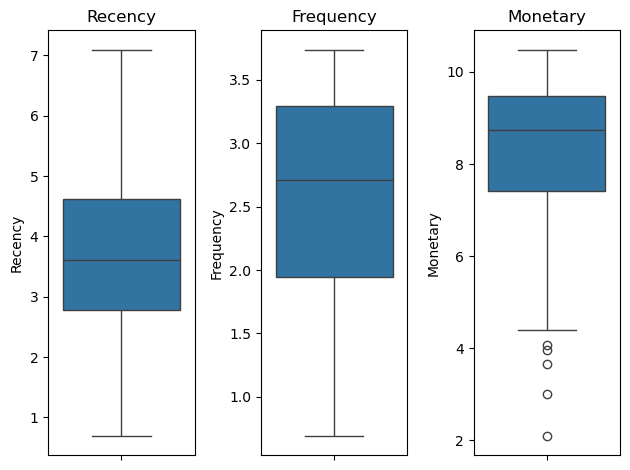

In [28]:
for item, col in enumerate(rfm.columns, 1):
    plt.subplot(1,3, item)
    sns.boxplot(rfm[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Standard Scaler

In [29]:
scale_pipe = Pipeline([("scale", StandardScaler())])

### K-Means

In [30]:
from sklearn.cluster import KMeans

In [31]:
kmodel = Pipeline([("scale_model", scale_pipe), ("kmean", KMeans(n_clusters = 5, random_state = 42))])

In [32]:
kmodel.fit(rfm)

,steps,"[('scale_model', ...), ('kmean', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('scale', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [33]:
cluster = kmodel.predict(rfm)

In [34]:
### Add the cluster labels to the Original RFM table
rfm_frame["Cluster"] = cluster

In [35]:
rfm_frame.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
AA-10315,9,19,13747.41300,3
AA-10375,7,23,5884.19500,3
AA-10480,126,20,17695.58978,1
AA-10645,29,36,15343.89070,1
AA-315,3,7,2243.25600,2


In [36]:
total_C = rfm_frame.groupby("Cluster").median()

In [37]:
total_C

,Recency,Frequency,Monetary
Cluster,,,
0,186.0,4.0,515.98500
1,34.0,25.5,13029.60213
2,22.0,7.0,1885.05000
3,6.0,27.0,13252.25330
4,142.0,6.0,2104.59600


### Definition of clusters
- If customer spends more than 13,100.00, then the customer is a `VIP customer`
- If the customer's recency is less than 10 days, frequency (order) of more than 25 and spends more than 13,000 on average, then customer is a `loyal`
- If customer's recency is less than 30 days, frequency is less than 10 and spends less than 2000 on average, the the customer is a `New Customer`
- If customer's recency is greater than 60 days, frequency is less than 10 and spends less than 2,500 on average, the the customer is a `At risk customer`
- If customer's recency is more than 60 days, frequency is less than 10 and spends less than 2000 on average, the the customer is a `lost customer`

In [38]:
def rfm_label(table):
    ### condition for VIP
    if table["Monetary"] >= 13_100:
        return "VIP Customer"
    ### Condition for loyal customers
    elif 10< table["Recency"] < 60 and table["Frequency"] > 20 and table["Monetary"] > 13_000:
        return "Loyal Customer"
    ### condition for new customers
    elif table["Recency"] < 30 and table["Frequency"] < 10 and table["Monetary"] < 2_000:
        return "New Customer"
    ### condition for at risk customers
    elif table["Recency"] > 60 and table["Frequency"] < 10 and table["Monetary"] > 2_000:
        return "At risk"
    elif table["Recency"] > 60 and table["Frequency"] < 10 and table["Monetary"] < 2_000:
        return "Lost Customer"

In [39]:
### Use the definition to create the clusters
total_C["Customer_class"]=total_C.apply(rfm_label,axis=1)

In [40]:
### Include a column on the customer table with the definition created
rfm_frame["Customer_class"] = rfm_frame["Cluster"].map({0:"Lost Customer", 
                                                        1:"Loyal Customer", 2:"New Customer",
                                                        3:"VIP Customer", 4:"At risk"})

In [41]:
rfm_frame.head()

,Recency,Frequency,Monetary,Cluster,Customer_class
Customer ID,,,,,
AA-10315,9,19,13747.41300,3,VIP Customer
AA-10375,7,23,5884.19500,3,VIP Customer
AA-10480,126,20,17695.58978,1,Loyal Customer
AA-10645,29,36,15343.89070,1,Loyal Customer
AA-315,3,7,2243.25600,2,New Customer


### PCA 

In [42]:
from sklearn.decomposition import PCA

In [43]:
rfm_scaled = scale_pipe.fit_transform(rfm)

In [44]:
pca = PCA(n_components = 2)

In [45]:
rfm_pca = pca.fit_transform(rfm_scaled)

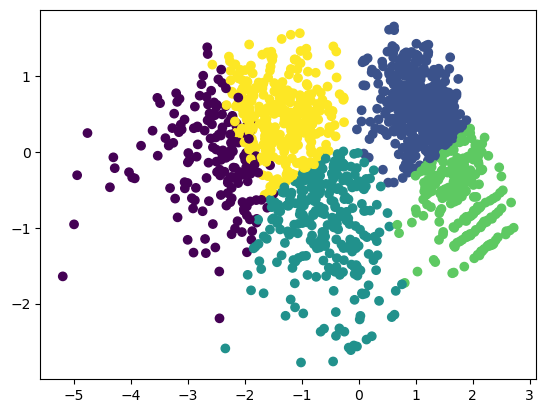

In [46]:
plt.scatter(rfm_pca[:,0], rfm_pca[:,1], c = cluster)
plt.show()